# **1. Install Dependencies**

In [1]:
!pip install datasets pillow matplotlib transformers

In [2]:
from datasets import load_dataset
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# **2. Load ChartQA Dataset**

In [3]:
dataset = load_dataset("HuggingFaceM4/ChartQA")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['image', 'query', 'label', 'human_or_machine'],
        num_rows: 28299
    })
    val: Dataset({
        features: ['image', 'query', 'label', 'human_or_machine'],
        num_rows: 1920
    })
    test: Dataset({
        features: ['image', 'query', 'label', 'human_or_machine'],
        num_rows: 2500
    })
})


# **3. Explore Dataset Structure**

In [4]:
sample = dataset["train"][0]

print(sample.keys())
print("Question:", sample["query"])
print("Answer:", sample["label"])
print("Image type:", type(sample["image"]))

dict_keys(['image', 'query', 'label', 'human_or_machine'])
Question: Is the value of Favorable 38 in 2015?
Answer: ['Yes']
Image type: <class 'PIL.PngImagePlugin.PngImageFile'>


# **4. Display Sample Charts**

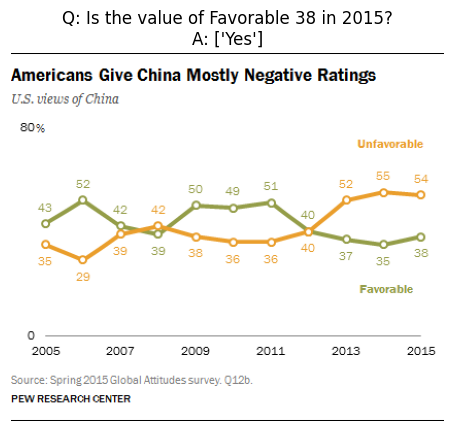

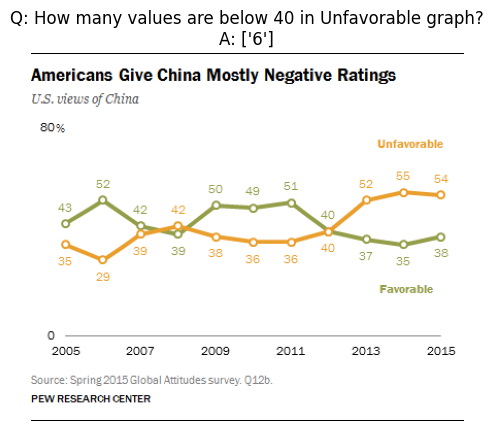

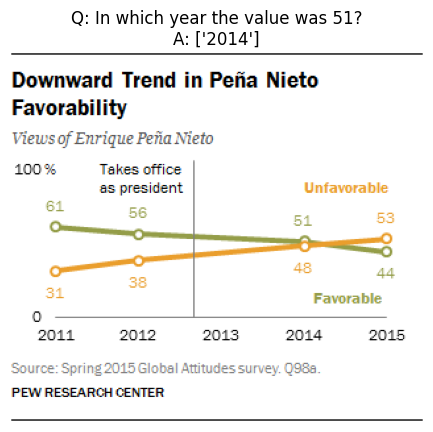

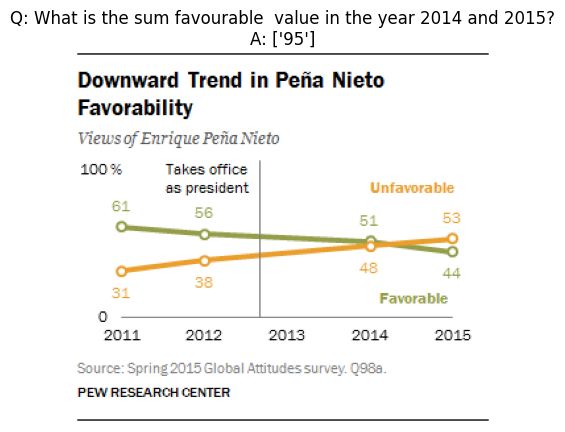

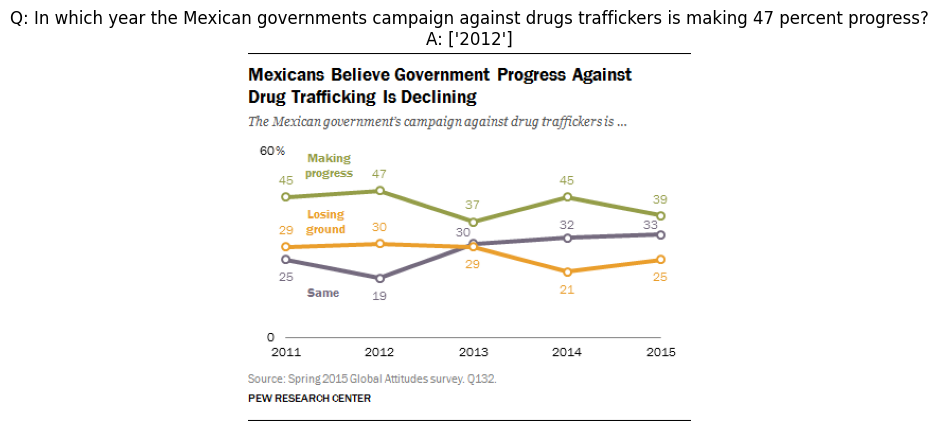

In [5]:
for i in range(5):
    sample = dataset["train"][i]

    plt.imshow(sample["image"])
    plt.title(f"Q: {sample['query']}\nA: {sample['label']}")
    plt.axis("off")
    plt.show()

# **5. Analyze Label Distribution**

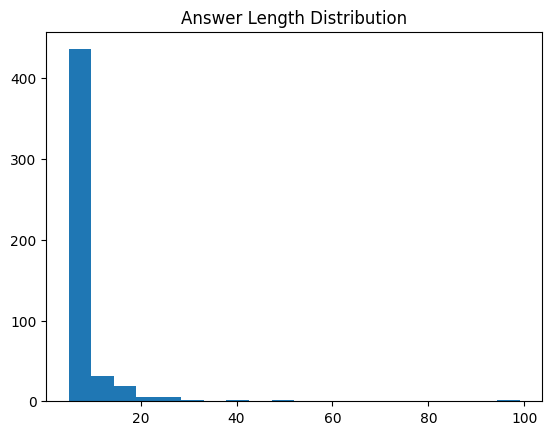

In [6]:
labels = [dataset["train"][i]["label"] for i in range(500)]

lengths = [len(str(x)) for x in labels]

plt.hist(lengths, bins=20)
plt.title("Answer Length Distribution")
plt.show()

# **6. Preprocess Images**
Images are resized to 448×448 to match the expected input resolution
of the Qwen2-VL vision-language model.

In [7]:
from transformers import AutoProcessor

processor = AutoProcessor.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct",
    trust_remote_code=True
)

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


(np.float64(-0.5), np.float64(447.5), np.float64(447.5), np.float64(-0.5))

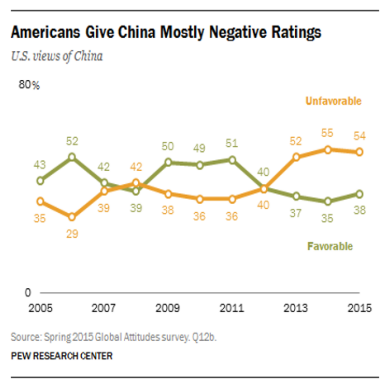

In [8]:
#Resize example image
image = dataset["train"][0]["image"]

image = image.resize((448,448))

plt.imshow(image)
plt.axis("off")

# **7. Tokenize Query + Label**

In [9]:
query = dataset["train"][0]["query"]
label = dataset["train"][0]["label"]

text = f"Question: {query}\nAnswer: {label}"

print(text)

Question: Is the value of Favorable 38 in 2015?
Answer: ['Yes']


In [10]:
inputs = processor(
    text=text,
    images=image,
    return_tensors="pt"
)

print(inputs.keys())

KeysView({'input_ids': tensor([[14582,    25,  2160,   279,   897,   315, 73787,   480,   220,    18,
            23,   304,   220,    17,    15,    16,    20,  5267, 16141,    25,
          2509,  9454,   660]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]), 'pixel_values': tensor([[ 1.9303,  1.9303,  1.9303,  ...,  2.1459,  2.1459,  2.1459],
        [ 1.9303,  1.9303,  1.9303,  ...,  2.1459,  2.1459,  2.1459],
        [ 1.9303,  1.9303,  1.9303,  ...,  1.9753,  0.4395, -1.4802],
        ...,
        [ 1.9303,  1.9303,  1.9303,  ...,  2.1459,  2.1459,  2.1459],
        [ 1.9303,  1.9303,  1.9303,  ...,  2.1459,  2.1459,  2.1459],
        [ 1.9303,  1.9303,  1.9303,  ...,  2.1459,  2.1459,  2.1459]]), 'image_grid_thw': tensor([[ 1, 32, 32]])})


# **8. Format Dataset**
Each example is formatted as:

Question: [query]

Answer: [label]

This format aligns with instruction-tuned multimodal models.

In [11]:
def preprocess(example):

    image = example["image"].resize((448,448))

    text = f"Question: {example['query']}\nAnswer: {example['label']}"

    inputs = processor(
        text=text,
        images=image,
        return_tensors="pt",
        padding="max_length",
        truncation=True
    )

    return inputs

In [12]:
processed_dataset = dataset["train"].select(range(100)).map(preprocess)

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

## Tests

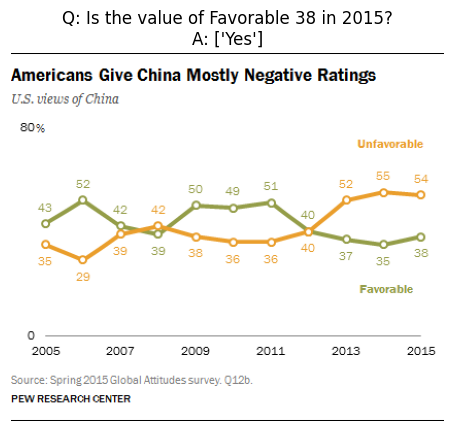

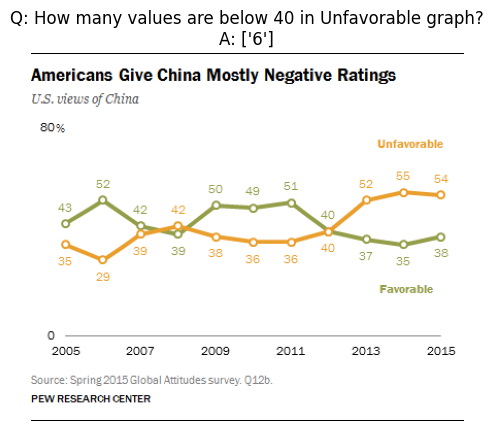

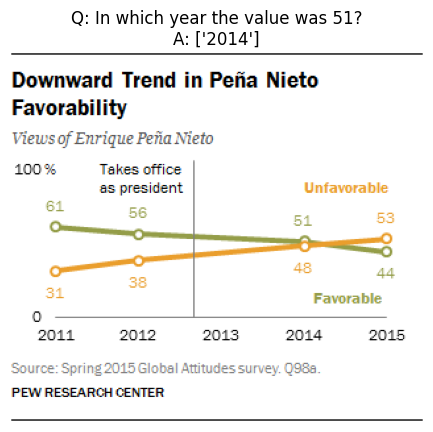

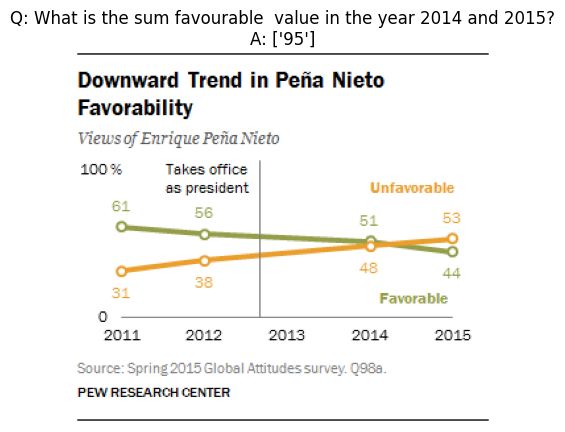

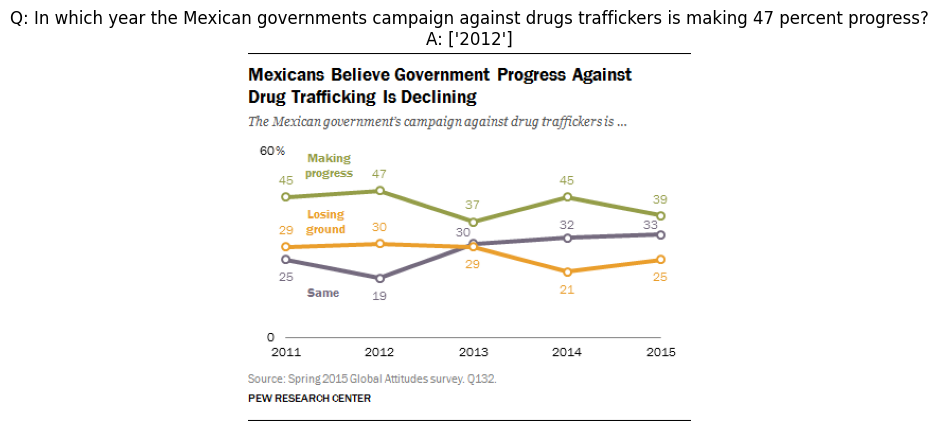

In [13]:
for i in range(5):
    sample = dataset["train"][i]

    plt.imshow(sample["image"])
    plt.title(f"Q: {sample['query']}\nA: {sample['label']}")
    plt.axis("off")
    plt.show()

The dataset contains chart images paired with natural language questions and answers.

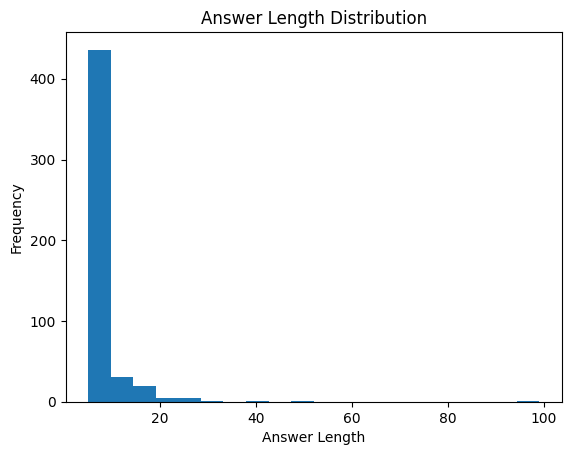

In [14]:
labels = [dataset["train"][i]["label"] for i in range(500)]

lengths = [len(str(x)) for x in labels]

plt.hist(lengths, bins=20)
plt.title("Answer Length Distribution")
plt.xlabel("Answer Length")
plt.ylabel("Frequency")
plt.show()

Most answers are short numeric or text values.

In [15]:
print("Train:", len(dataset["train"]))
print("Validation:", len(dataset["val"]))
print("Test:", len(dataset["test"]))

Train: 28299
Validation: 1920
Test: 2500


The dataset already provides predefined training, validation, and test splits.

In [16]:
test = dataset["train"].select(range(1)).map(preprocess)

print(test)

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'query', 'label', 'human_or_machine', 'input_ids', 'attention_mask', 'pixel_values', 'image_grid_thw'],
    num_rows: 1
})


This shows the dataset now contains model-ready tensors.

## Scripts to save and load the dataset

In [17]:
from datasets import DatasetDict

processed = DatasetDict({
    "train": dataset["train"].select(range(100)),
    "val": dataset["val"].select(range(100)),
    "test": dataset["test"].select(range(100))
})

processed.save_to_disk("chartqa_processed")

Saving the dataset (0/1 shards):   0%|          | 0/100 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/100 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/100 [00:00<?, ? examples/s]

In [20]:
'''
#dataset loading script
from datasets import load_from_disk
dataset = load_from_disk("chartqa_processed")
'''

'\n#dataset loading script\nfrom datasets import load_from_disk\ndataset = load_from_disk("chartqa_processed")\n'

## Script to save dataset to drive

In [22]:
import os
os.listdir("/content")
os.listdir("/content/chartqa_processed")

['train', 'val', 'test', 'dataset_dict.json']

Save to drive

In [28]:
'''
from google.colab import drive
drive.mount('/content/drive')

processed.save_to_disk("/content/drive/MyDrive/chartqa_processed")
'''

rm: cannot remove '/content/drive/MyDrive': Operation canceled
rm: cannot remove '/content/drive/.shortcut-targets-by-id': Operation canceled
rm: cannot remove '/content/drive/.Trash-0': Directory not empty
rm: cannot remove '/content/drive/.Encrypted/MyDrive': Operation canceled
rm: cannot remove '/content/drive/.Encrypted/.shortcut-targets-by-id': Operation canceled
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving the dataset (0/1 shards):   0%|          | 0/100 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/100 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/100 [00:00<?, ? examples/s]

Load from drive

In [29]:
from datasets import load_from_disk

test_load = load_from_disk("/content/drive/MyDrive/chartqa_processed")

print(test_load)

DatasetDict({
    train: Dataset({
        features: ['image', 'query', 'label', 'human_or_machine'],
        num_rows: 100
    })
    val: Dataset({
        features: ['image', 'query', 'label', 'human_or_machine'],
        num_rows: 100
    })
    test: Dataset({
        features: ['image', 'query', 'label', 'human_or_machine'],
        num_rows: 100
    })
})
